In [17]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [18]:
df = pd.read_csv("50_Startups.csv")

In [19]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [20]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [21]:
states = pd.get_dummies(x["State"],drop_first=True,dtype=float)

In [22]:
x = x.drop("State",axis=1)

In [23]:
x = pd.concat([x,states],axis=1)

In [24]:
x.head()

,R&D Spend,Administration,Marketing Spend,Florida,New York
0,165349.20,136897.80,471784.10,0.0,1.0
1,162597.70,151377.59,443898.53,0.0,0.0
2,153441.51,101145.55,407934.54,1.0,0.0
3,144372.41,118671.85,383199.62,0.0,1.0
4,142107.34,91391.77,366168.42,1.0,0.0


In [25]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0 )

In [26]:
from sklearn.linear_model import LinearRegression 
regressor = LinearRegression() 
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = regressor.predict(x_test)

In [29]:
y_pred

array([103015.20159796, 132582.27760816, 132447.73845174,  71976.09851258,
       178537.48221055, 116161.24230165,  67851.69209676,  98791.73374687,
       113969.43533012, 167921.0656955 ])

In [30]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)

In [32]:
print(round(score*100,2))

93.47


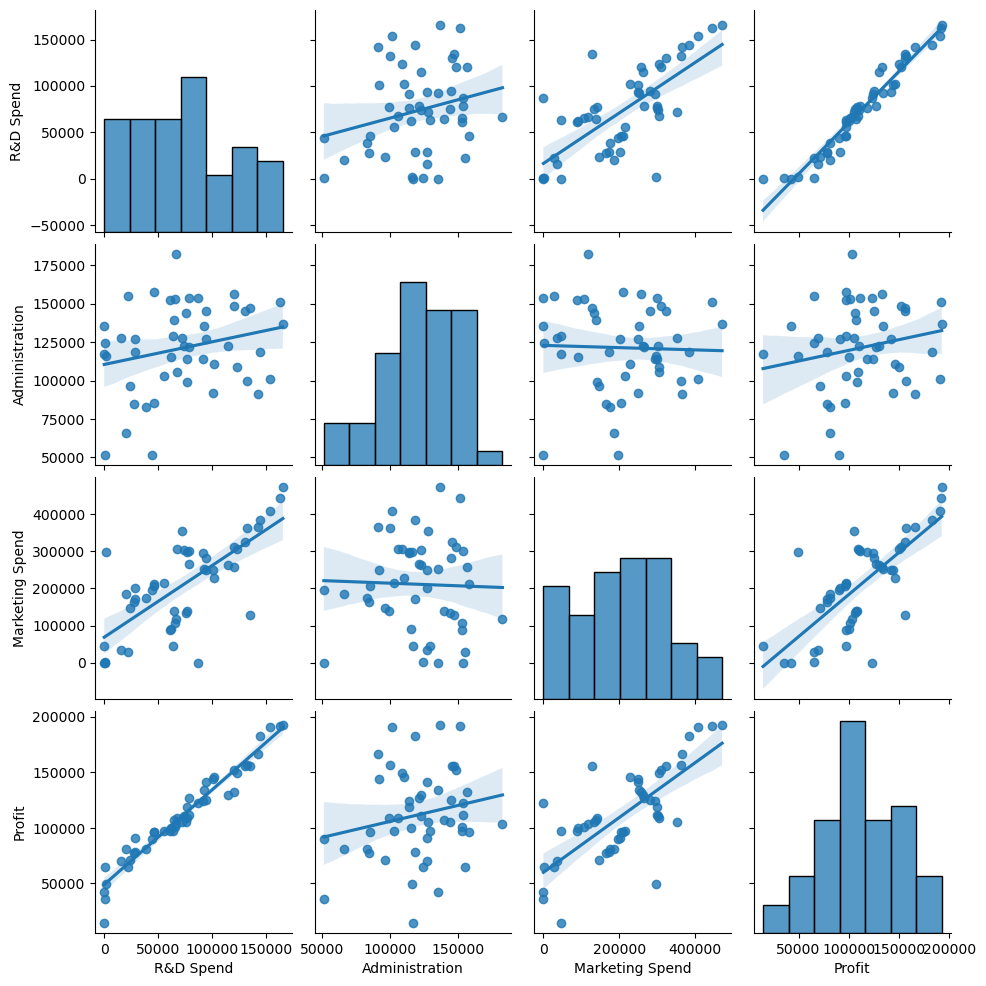

In [35]:
sns.pairplot(df,kind="reg")

In [36]:
df.shape

(50, 5)